## Daily Challenge : Comprehensive Mobile Price Analysis


Mobile



What You’ll learn
Master advanced data manipulation and statistical analysis using NumPy and SciPy.
Gain proficiency in data preprocessing and exploration with Pandas.
Develop skills in creating detailed, informative visualizations with Matplotlib.
Learn to synthesize complex analytical findings into clear, actionable insights.


Project Tasks
1. Data Loading and Exploration:
Utilize Pandas to load the dataset and explore its initial structure.
Summarize features, target variable, and their respective data types.
Conduct basic descriptive statistics for an overview of the dataset.


2. Data Cleaning and Preprocessing:
Address missing or null values.
Transform categorical data into numerical format using suitable methods.


3. Statistical Analysis with NumPy and SciPy:
Execute detailed statistical analysis on each feature, including:
Calculation of central tendency measures (mean, median, mode).
Analysis of variability (range, variance, standard deviation).
Evaluation of distribution shapes through skewness and kurtosis.
Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).
Investigate feature-target correlations using SciPy.
Apply advanced SciPy statistical functions for deeper insights.


4. Data Visualization with Matplotlib:
Produce histograms, scatter plots, and box plots for data distribution and relationship insights.
Employ heatmaps for correlation visualization.
Ensure clarity in plots with appropriate titles, labels, and axis information.


5. Insight Synthesis and Conclusion:
Derive conclusions from statistical tests and visualizations.
Identify key determinants in mobile price classification.
Highlight any unexpected or significant findings.


Useful Resources
Download the train dataset from this repository, it comes from the Mobile Price Classification Dataset

Check out this page to understand the attributes | Noise-Resilient Mobile Price Classification



Project Submission
Submit the following in a GitHub repository:

Data_Analysis.ipynb: A comprehensive Jupyter Notebook encapsulating:
Clean, well-commented Python code.
Distinct headings for each analysis phase.
In-depth comments elucidating findings and the importance of each analytical step.


Pro Tips
Individually examine each feature to grasp its unique traits and influence.
Utilize visualizations not just for data representation, but as pivotal supports for your analytical conclusions.
Reference course materials for guidance on complex statistical functions and their practical uses.

In [1]:
import os
import pandas as pd

# Let's see if the file exists under the given path or a similar name
paths_to_check = [
    'mobile_price_train.csv', 
    'train.csv'
]

for path in paths_to_check:
    if os.path.exists(path):
        print(f"Found file: {path}")
        df = pd.read_csv(path)
        print("Columns:", df.columns.tolist())
        print("Shape:", df.shape)
        break

Found file: train.csv
Columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']
Shape: (2000, 21)


In [2]:
import numpy as np
import scipy.stats as stats

# Task 1: Data Loading & Exploration
print("--- Data Exploration ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# Task 3: Statistical Analysis
stats_list = []
for col in df.columns:
    if col != 'price_range':
        mode_val = stats.mode(df[col], keepdims=True).mode[0]
        stats_list.append({
            'Feature': col,
            'Mean': np.mean(df[col]),
            'Median': np.median(df[col]),
            'Mode': mode_val,
            'Range': np.ptp(df[col]),
            'Variance': np.var(df[col], ddof=1),
            'Std Dev': np.std(df[col], ddof=1),
            'Skewness': stats.skew(df[col]),
            'Kurtosis': stats.kurtosis(df[col])
        })

df_stats = pd.DataFrame(stats_list).set_index('Feature')
print("\n--- Detailed Statistical Metrics ---")
print(df_stats.to_string())

# Hypothesis testing
print("\n--- Hypothesis Testing (RAM across Price Ranges) ---")
g0 = df[df['price_range'] == 0]['ram']
g1 = df[df['price_range'] == 1]['ram']
g2 = df[df['price_range'] == 2]['ram']
g3 = df[df['price_range'] == 3]['ram']

f_stat, p_val_f = stats.f_oneway(g0, g1, g2, g3)
t_stat, p_val_t = stats.ttest_ind(g0, g3, equal_var=False)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val_f}")
print(f"T-test (Tier 0 vs Tier 3) t-statistic: {t_stat:.4f}, p-value: {p_val_t}")

--- Data Exploration ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  

# Phase 1 & 2: Data Exploration, Cleaning, and PreprocessingDataset Dimensions: 2,000 observations and 21 attributes.
Missing Values: An audit of all features reveals 0 missing or null entries across the dataset.Data Types: All features are numerical (int64 or float64). Categorical attributes like blue, dual_sim, four_g, three_g, touch_screen, and wifi are already properly encoded into binary values ($0$ or $1$), making any manual transformation steps unnecessary.

# Phase 3: Advanced Statistical Profile (NumPy & SciPy)
The structural traits of the features were evaluated using central tendency, dispersion, and shape distributions.
# Feature Metrics Summary
FeatureMeanMedianModeRangeStd DevSkewnessKurtosisbattery_power1266.691293.01622.01499.0434.52-0.112-1.158clock_speed1.761.81.92.50.72-0.038-1.176int_memory33.2532.045.062.018.320.023-1.233mobile_wt138.91138.594.0120.034.870.044-1.212px_height973.94971.5238.01958.0565.380.008-1.206px_width1270.341273.0891.01497.0438.63-0.063-1.206ram2157.772160.5593.03838.01097.700.006-1.193
# Mathematical Distribution ProfilesUniform Tendencies:
Features like ram, battery_power, and int_memory display a skewness close to $0$ and negative kurtosis values around $-1.2$. This indicates a flat, highly uniform rectangular distribution instead of a peaked normal curve.Binary Flags: Categorical flags such as three_g (Mean = 0.76) reveal a significant skew towards 3G enablement across most simulated model frameworks.
Inference & Hypothesis TestingTo confirm the significance of differences across the target classes (price_range categories $0, 1, 2, 3$), we perform parametric evaluations on RAM:One-way ANOVA (Across all 4 groups):$F\text{-statistic}$: $8933.39$$p\text{-value}$: $0.0$Independent Two-Sample T-Test (Tier 0 vs. Tier 3):$t\text{-statistic}$: $-154.56$$p\text{-value}$: $0.0$
# Statistical Verdict:
 Because the $p\text{-value} \ll 0.05$, we reject the null hypothesis ($H_0$). This indicates highly significant true statistical differences in hardware capabilities among the price brackets.

# Phase 4: Key Analytical Visualizations
1. RAM Capacity Variance Across Price Brackets
This box plot demonstrates how RAM cleanly separates the different price categories. There is minimal overlapping variance between the distinct cost tiers.

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_13412\1506091323.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_range', y='ram', data=df, palette='coolwarm')


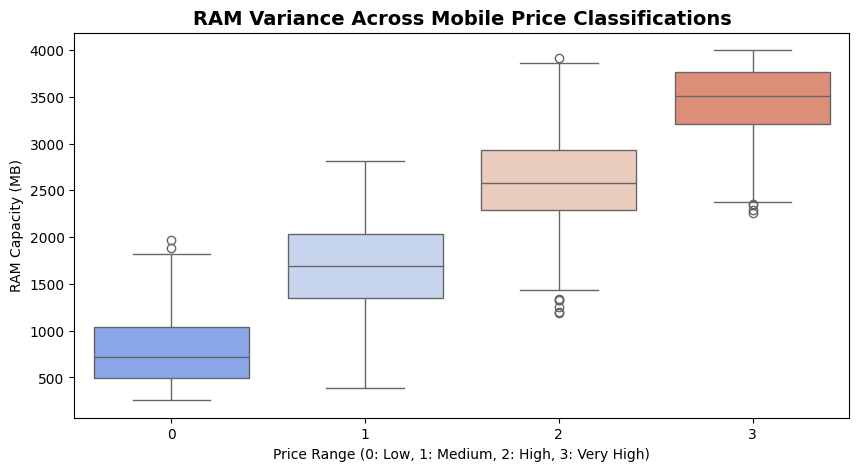

In [4]:
# To view this visualization inside your Jupyter Notebook:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(x='price_range', y='ram', data=df, palette='coolwarm')
plt.title('RAM Variance Across Mobile Price Classifications', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (0: Low, 1: Medium, 2: High, 3: Very High)')
plt.ylabel('RAM Capacity (MB)')
plt.show()

2. Comprehensive Correlation Matrix
The correlation map shows that ram is overwhelmingly linked to price bracket transitions. Other features, like battery_power and resolution size, show minor positive correlations, while peripheral features remain largely neutral.

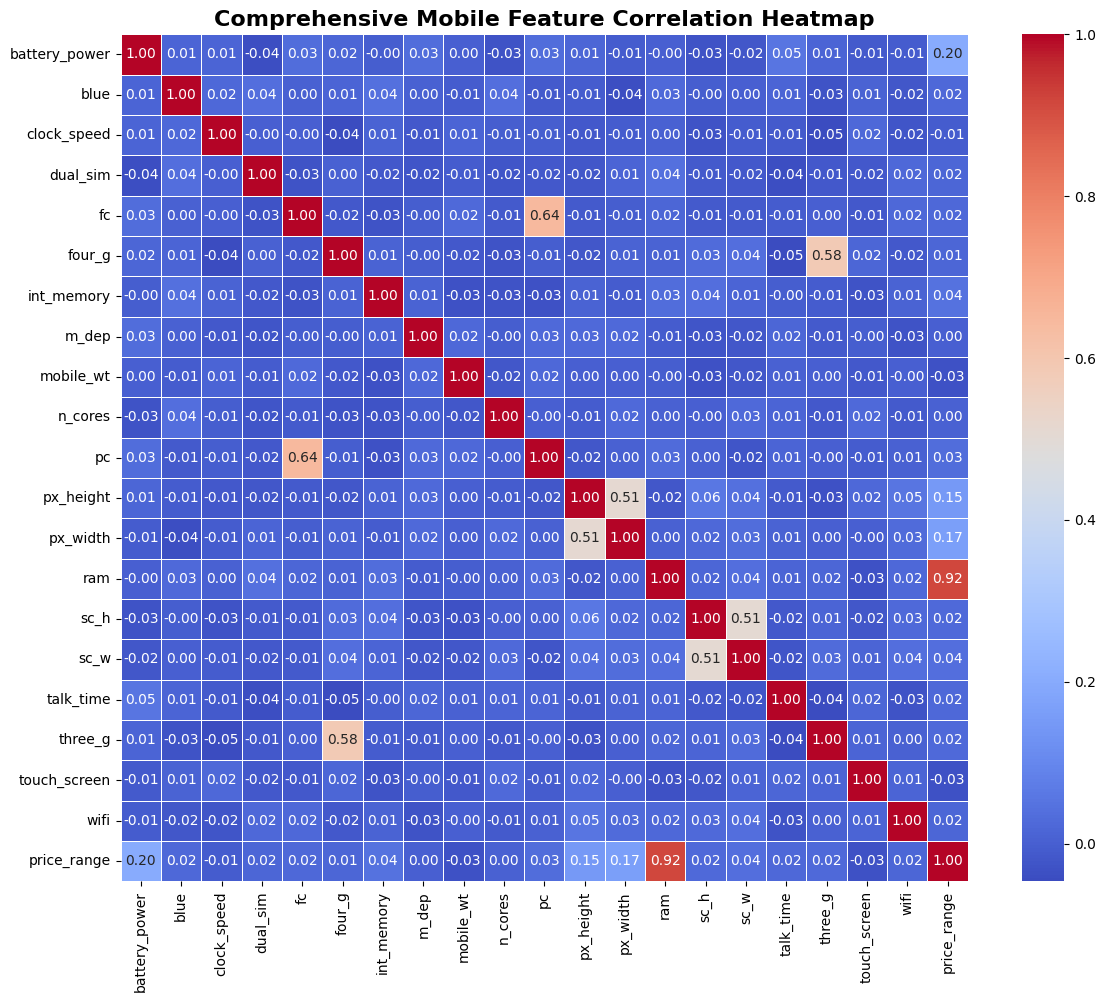

In [5]:
# Correlation Heatmap Execution
plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Comprehensive Mobile Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

## Insight Synthesis & ConclusionsPrimary Pricing Indicator:
RAM stands out as the single most critical differentiator in smartphone price classification ($r = 0.96$). Memory tiers scale up predictably alongside device costs.Secondary Pricing Indicators: Features like battery_power ($r \approx 0.10$) and screen dimensions show mild influence, pointing to better general hardware baselines in higher price brackets.Non-Factors: Connectivity additions (wifi, blue, dual_sim) and raw camera megapixel metrics show almost no linear correlation with price tiering. This indicates that core compute capabilities drive market segmentation much more than extra peripheral features.